# Mengambil data dari yahoo finance

In [1]:
from datetime import datetime
import yfinance as yf

# Simbol pasar IHSG di Yahoo Finance
simbol = "^JKSE"

# Rentang waktu
tanggal_mulai = "2023-01-01"
tanggal_akhir = datetime.today().strftime("%Y-%m-%d")

# Pengunduhan data harian
df_ihsg = yf.download(
    tickers=simbol,
    start=tanggal_mulai,
    end=tanggal_akhir,
    interval="1d",
    auto_adjust=False,
)

# Menampilkan lima baris pertama dan terakhir
df_ihsg.head()


[*********************100%***********************]  1 of 1 completed

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^JKSE,^JKSE,^JKSE,^JKSE,^JKSE,^JKSE
Date,,,,,,
2023-01-02,6850.983887,6850.983887,6856.889160,6823.479004,6850.740234,109645000
2023-01-03,6888.757812,6888.757812,6908.001953,6838.574219,6850.983887,156894900
2023-01-04,6813.238770,6813.238770,6900.603027,6813.238770,6888.798828,142541400
2023-01-05,6653.840820,6653.840820,6813.421875,6621.986816,6813.279785,180589300
2023-01-06,6684.558105,6684.558105,6708.637207,6598.645996,6653.759766,109855600


## Pembersihan Data (Data Cleansing)

In [2]:
import pandas as pd
import numpy as np
import io
import ydata_profiling
df = df_ihsg.copy()
# Meratakan MultiIndex kolom dari yfinance agar mudah diakses
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Check kolom yang memiliki missing data
print('Check kolom yang memiliki missing data:')
print(df.isnull().any())

Check kolom yang memiliki missing data:
Price
Adj Close    False
Close        False
High         False
Low          False
Open         False
Volume       False
dtype: bool


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11440\3191997217.py:4: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling


Setelah memastikan tidak ada data yang kosong (missing values), langkah berikutnya adalah mendeteksi pencilan (outliers). 

Fokus pencarian pencilan dibatasi hanya pada kolom Volume. Fluktuasi tajam pada kolom harga umumnya dibiarkan utuh karena data tersebut mencerminkan volatilitas pasar yang sebenarnya (bukan kesalahan data). 

Kita gunakan histogram untuk melihat bentuk distribusi data Volume. Langkah ini penting untuk menentukan metode statistik mana yang paling tepat.

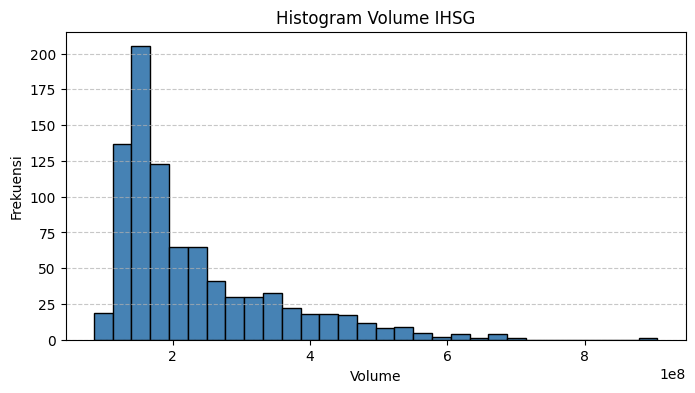

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df["Volume"], bins=30, color="steelblue", edgecolor="black")
plt.title("Histogram Volume IHSG")
plt.xlabel("Volume")
plt.ylabel("Frekuensi")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Histogram di atas menunjukkan distribusi yang miring ke kanan (right-skewed) dan tidak normal. Oleh karena itu, kita menggunakan metode Interquartile Range (IQR) karena jauh lebih akurat untuk data yang tidak simetris. 

In [4]:
from pandas.core.interchange import dataframe
import pandas as pd 
import numpy as np 

# Cek jumlah baris awal
print(f"shape awal: {df.shape}")

# menghitung Q1, Q3, dan IQR
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1

# menghitung batas atas dan bawah 
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# mendeteksi data pencilan
data_pencilan = len(df[(df['Volume'] < batas_bawah) | (df['Volume'] > batas_atas)])
print(f"jumlah pencilan: {data_pencilan}")

# Menangani pencilan dengan teknik Capping (Winsorization) agar baris data waktu tetap utuh
df_bersih = df.copy()
df_bersih.loc[df_bersih['Volume'] > batas_atas, 'Volume'] = batas_atas
df_bersih.loc[df_bersih['Volume'] < batas_bawah, 'Volume'] = batas_bawah

# Cek jumlah baris akhir untuk memastikan tidak ada data yang terhapus
print(f"shape akhir (setelah capping, baris harus utuh): {df_bersih.shape}")

shape awal: (870, 6)
jumlah pencilan: 47
shape akhir (setelah capping, baris harus utuh): (870, 6)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11440\4225657318.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '465240262.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_bersih.loc[df_bersih['Volume'] > batas_atas, 'Volume'] = batas_atas


In [5]:
df_bersih = df_bersih.copy()

# menghitung log return dari kolom 'ajd close'_AddableT1
df_bersih['Log_Return'] = np.log(df_bersih['Adj Close'])
df_bersih['Adj Close'].shift(1)

# menghapus data pertama 
df_bersih = df_bersih.dropna()

# melihat 5 baris pertama 
df_bersih[['Adj Close', 'Log_Return']].head()

Price,Adj Close,Log_Return
Date,,
2023-01-02,6850.983887,8.832148
2023-01-03,6888.757812,8.837646
2023-01-04,6813.238770,8.826623
2023-01-05,6653.840820,8.802950
2023-01-06,6684.558105,8.807555


## Transformasi Data (Log Return)
Harga saham harian umumnya tidak stasioner. Sebagai gantinya, kita menggunakan nilai Log Return yang jauh lebih stabil untuk keperluan pemodelan stokastik.

In [6]:
# Menyalin dataframe untuk menghindari peringatan SettingWithCopyWarning
df_bersih = df_bersih.copy()

# 1. Menghitung Log Return dari kolom 'Adj Close'
# Rumus: ln( Harga Hari Ini / Harga Kemarin )
df_bersih['Log_Return'] = np.log(df_bersih['Adj Close'] / df_bersih['Adj Close'].shift(1))

# 2. Menghapus baris pertama karena tidak memiliki nilai return
df_bersih = df_bersih.dropna()

# 3. Menampilkan sampel hasil perhitungan
display(df_bersih[['Adj Close', 'Log_Return']].head())

Price,Adj Close,Log_Return
Date,,
2023-01-03,6888.757812,0.005499
2023-01-04,6813.238770,-0.011023
2023-01-05,6653.840820,-0.023673
2023-01-06,6684.558105,0.004606
2023-01-09,6688.265137,0.000554


## Uji Stasioneritas (Augmented Dickey-Fuller)
Langkah terakhir adalah membuktikan bahwa data Log Return benar-benar stasioner secara matematis.
Jika nilai p-value di bawah 0.05, hipotesis nol ditolak dan data dinyatakan siap untuk masuk ke tahap pemodelan.

In [7]:
from statsmodels.tsa.stattools import adfuller

# Melakukan uji ADF pada kolom Log Return
hasil_adf = adfuller(df_bersih['Log_Return'])

print('Hasil Uji Augmented Dickey-Fuller:')
print(f'ADF Statistic: {hasil_adf[0]}')
print(f'p-value: {hasil_adf[1]}')

print('\nKesimpulan:')
if hasil_adf[1] < 0.05:
    print('p-value < 0.05: Tolak H0. Data Log Return SUDAH stasioner.')
else:
    print('p-value >= 0.05: Gagal tolak H0. Data BELUM stasioner.')

Hasil Uji Augmented Dickey-Fuller:
ADF Statistic: -15.916849294380105
p-value: 8.006328530568995e-29

Kesimpulan:
p-value < 0.05: Tolak H0. Data Log Return SUDAH stasioner.


## Mengunduh Bersih

In [8]:
df_bersih.to_csv("../data/raw/ihsg_daily.csv")